In [64]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [65]:
df = pd.read_csv("data_preprocessed.csv")


# Cluster_A (Score & Votes)

- Cluster 0 → popular & high rated (green)  
- Cluster 1 → unpopular & low rated (purple)  
- Cluster 2 → mixed / average (yellow)  

This groups movies based on popularity and rating.

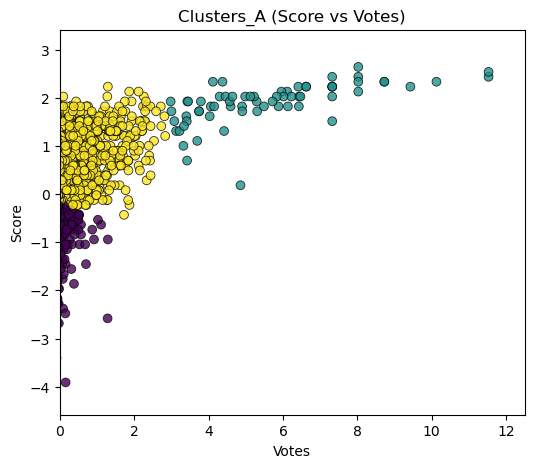

<Figure size 640x480 with 0 Axes>

In [66]:
X_A = df[['score', 'votes']]

kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster_A'] = kmeans.fit_predict(X_A)

plt.figure(figsize=(6,5))
plt.scatter(
    df['votes'], 
    df['score'], 
    c=df['cluster_A'], 
    cmap='viridis',
    alpha=0.8, 
    s=40,   
    edgecolors='black',  
    linewidths=0.6
)
plt.xlabel("Votes")
plt.ylabel("Score")
plt.title("Clusters_A (Score vs Votes)")
plt.xlim(0, 12.5)
plt.show()

plt.savefig("clusters_A_plot.png")

# Cluster_B (Budget & Gross)

- Cluster 0 → high budget & high gross (green)  
- Cluster 1 → low budget & low gross (purple)  
- Cluster 2 → mixed / inefficient (yellow)  

This shows how movies perform financially.

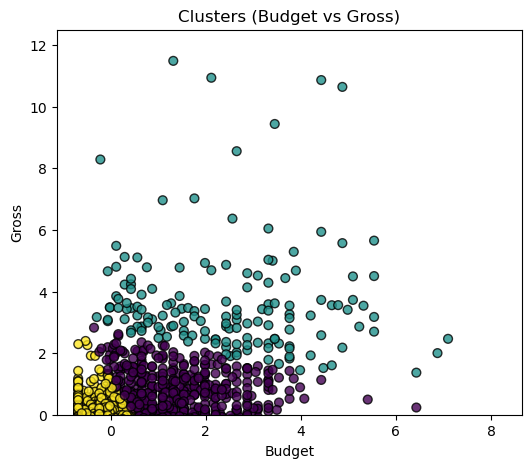

In [67]:
X_B = df[['budget', 'gross']]

kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster_B'] = kmeans.fit_predict(X_B)

plt.figure(figsize=(6,5))

plt.scatter(
    df['budget'], df['gross'],
    c=df['cluster_B'],
    cmap='viridis',
    alpha=0.8,
    s=40,
    edgecolors='black',
)

plt.xlabel("Budget")
plt.ylabel("Gross")
plt.title("Clusters (Budget vs Gross)")
plt.ylim(0, 12.5)
plt.savefig("clusters_B.png") 
plt.show()

# Cluster_C (All Features)

- Cluster 0 → high budget, high gross, high votes (green)  
- Cluster 1 → low budget, low gross, low votes (purple)  
- Cluster 2 → average movies with moderate performance (yellow)  

This groups movies based on overall behavior.

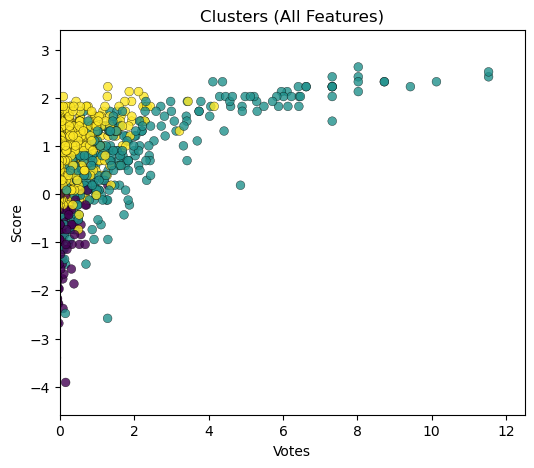

In [68]:
X_C = df[['score', 'votes', 'gross', 'budget', 'runtime']]

kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster_C'] = kmeans.fit_predict(X_C)

plt.figure(figsize=(6,5))

plt.scatter(
    df['votes'], df['score'],
    c=df['cluster_C'],
    cmap='viridis',
    alpha=0.8,
    s=40,
    edgecolors='black',
    linewidths=0.3
)
'''
The clustering is 5D which is very complex
The plot is 2D just for visualization
'''
plt.xlabel("Votes")
plt.ylabel("Score")
plt.title("Clusters (All Features)")
plt.xlim(0, 12.5)
plt.savefig("clusters_C.png") 
plt.show()

Clusters.txt

In [74]:
cluster_counts = {
    "cluster_A": df['cluster_A'].value_counts().sort_index(),
    "cluster_B": df['cluster_B'].value_counts().sort_index(),
    "cluster_C": df['cluster_C'].value_counts().sort_index()
}

cluster_labels = {
    "cluster_A (Score vs Votes)": ["popular & high rated", "unpopular & low rated", "mixed / average"],
    "cluster_B (Budget vs Gross)": ["high budget & gross", "low budget & gross", "medium performance"],
    "cluster_C (All Features)": ["high score & votes & gross & budget & runtime", 
                                  "low everything", 
                                  "average/mixed"]
}

cluster_mapping = {
    "cluster_A": "cluster_A (Score vs Votes)",
    "cluster_B": "cluster_B (Budget vs Gross)",
    "cluster_C": "cluster_C (All Features)"
}

with open("clusters.txt", "w") as f:
    for cluster_name, counts in cluster_counts.items():
        descriptive_name = cluster_mapping[cluster_name]
        f.write(f"{descriptive_name}:\n")
        f.write("Number of movies in each cluster:\n")
        labels = cluster_labels[descriptive_name]
        for i, count in counts.items():
            f.write(f"Cluster {i} ({labels[i]}): {count} movies\n")
        f.write("\n")

print("clusters.txt created")

clusters.txt created
